#📘 Firstly we begin with importing the libraries

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

#🗄️ Then we collecting and preparing the data, using inner joins to get the values we need to perceed with our Data Analysis

In [68]:
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

In [69]:
product_sells_helper = order_payments.merge(order_items, on='order_id')
product_sells = product_sells_helper.merge(products, on='product_id')
product_sells

,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,1,af74cc53dcffc8384b29e7abfa41902b,213b25e6f54661939f11710a6fddb871,2018-05-02 22:15:09,79.80,19.53,casa_construcao,57.0,921.0,8.0,800.0,17.0,27.0,17.0
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,1,a630cc320a8c872f9de830cf121661a3,eaf6d55068dea77334e8477d3878d89e,2018-07-02 11:18:58,17.00,7.39,automotivo,59.0,1274.0,2.0,150.0,16.0,6.0,11.0
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,1,2028bf1b01cafb2d2b1901fca4083222,cc419e0650a3c5ba77189a1882b7556a,2017-12-26 09:52:34,56.99,8.72,perfumaria,54.0,1536.0,2.0,250.0,20.0,8.0,21.0
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,1,548e5bfe28edceab6b51fa707cc9556f,da8622b14eb17ae2831f4ac5b9dab84a,2017-12-12 12:13:20,89.90,17.88,cama_mesa_banho,60.0,188.0,1.0,1200.0,44.0,2.0,35.0
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,1,386486367c1f9d4f587a8864ccb6902b,cca3071e3e9bb7d12640c9fbe2301306,2018-05-31 16:14:41,113.57,14.88,cama_mesa_banho,54.0,120.0,1.0,835.0,40.0,9.0,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117596,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31,1,1302fd16bdfe85e523940c846370ef2c,a369d693961cb93b61ca2cc518872a85,2018-03-15 03:55:25,297.00,66.31,construcao_ferramentas_iluminacao,31.0,309.0,1.0,13450.0,95.0,30.0,20.0
117597,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80,1,fb55982be901439613a95940feefd9ee,3d871de0142ce09b7081e2b9d1733cb1,2017-08-24 10:04:56,79.00,17.80,papelaria,52.0,211.0,2.0,7000.0,60.0,20.0,30.0
117598,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77,1,848ef0a103ee21407d1fbd0f7e7ae179,3d621842b2ed28e2b474132480edac3c,2017-11-27 17:46:05,39.99,7.78,automotivo,47.0,577.0,2.0,120.0,16.0,8.0,11.0
117599,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54,1,e9c1abcc7126360336d8f56d49041a8c,679769a98cfcc6da877c8486ff1c13f3,2018-08-13 23:45:00,349.00,20.54,beleza_saude,42.0,3902.0,7.0,500.0,22.0,6.0,16.0


In [70]:
#we want to get rid of the unnecessary columns
product_sells.drop(columns=['order_id', 'product_id', 'order_item_id', 'seller_id', 'payment_type','product_name_lenght','product_description_lenght', 'product_photos_qty', 'product_weight_g', 	'product_length_cm'	,'product_height_cm', 'product_width_cm'])

,payment_sequential,payment_installments,payment_value,shipping_limit_date,price,freight_value,product_category_name
0,1,8,99.33,2018-05-02 22:15:09,79.80,19.53,casa_construcao
1,1,1,24.39,2018-07-02 11:18:58,17.00,7.39,automotivo
2,1,1,65.71,2017-12-26 09:52:34,56.99,8.72,perfumaria
3,1,8,107.78,2017-12-12 12:13:20,89.90,17.88,cama_mesa_banho
4,1,2,128.45,2018-05-31 16:14:41,113.57,14.88,cama_mesa_banho
...,...,...,...,...,...,...,...
117596,1,1,363.31,2018-03-15 03:55:25,297.00,66.31,construcao_ferramentas_iluminacao
117597,1,2,96.80,2017-08-24 10:04:56,79.00,17.80,papelaria
117598,1,1,47.77,2017-11-27 17:46:05,39.99,7.78,automotivo
117599,1,5,369.54,2018-08-13 23:45:00,349.00,20.54,beleza_saude


In [71]:
product_sells = product_sells.drop(columns=['order_id', 'product_id', 'order_item_id', 'seller_id', 'payment_type','product_name_lenght','product_description_lenght', 'product_photos_qty', 'product_weight_g', 	'product_length_cm'	,'product_height_cm', 'product_width_cm'])

In [72]:
final_profits = product_sells.groupby('product_category_name')['payment_value'].sum()
#now we can see that the cama_mesa_banho is the most popular category which have generated the biggest profit
final_profits.sort_values(ascending=False)

,payment_value
product_category_name,
cama_mesa_banho,1712553.67
beleza_saude,1657373.12
informatica_acessorios,1585330.45
moveis_decoracao,1430176.39
relogios_presentes,1429216.68
...,...
pc_gamer,2174.43
casa_conforto_2,1710.54
cds_dvds_musicais,1199.43


#🔬 Our adventure continues into diving deeper in analyzing the financial business part of the datasets - we can come up with efficient Increental Profit Hypothesis - by getting the top categories

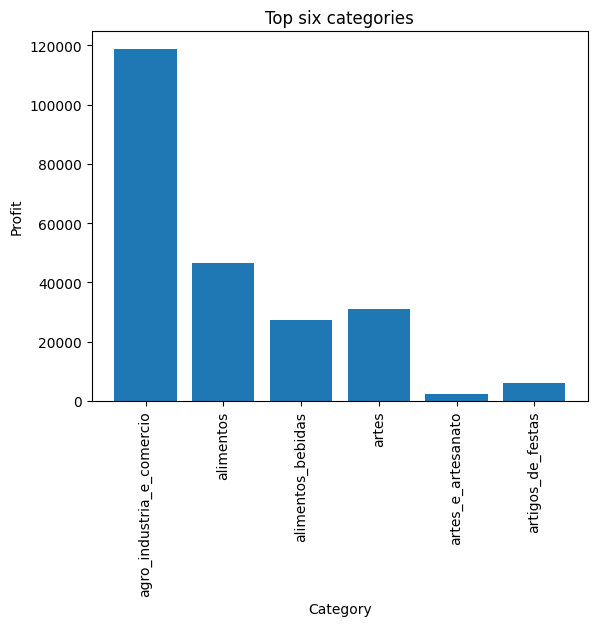

In [73]:
top_products = final_profits.head(6)
plt.bar(top_products.index, top_products.values)
plt.xticks(rotation=90)
plt.title('Top six categories')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()
#so now the company can see which categories of products brings to the company the biggest profit and which do not, so
#they can stop producing them and be on lost

In [74]:
product_sells

,payment_sequential,payment_installments,payment_value,shipping_limit_date,price,freight_value,product_category_name
0,1,8,99.33,2018-05-02 22:15:09,79.80,19.53,casa_construcao
1,1,1,24.39,2018-07-02 11:18:58,17.00,7.39,automotivo
2,1,1,65.71,2017-12-26 09:52:34,56.99,8.72,perfumaria
3,1,8,107.78,2017-12-12 12:13:20,89.90,17.88,cama_mesa_banho
4,1,2,128.45,2018-05-31 16:14:41,113.57,14.88,cama_mesa_banho
...,...,...,...,...,...,...,...
117596,1,1,363.31,2018-03-15 03:55:25,297.00,66.31,construcao_ferramentas_iluminacao
117597,1,2,96.80,2017-08-24 10:04:56,79.00,17.80,papelaria
117598,1,1,47.77,2017-11-27 17:46:05,39.99,7.78,automotivo
117599,1,5,369.54,2018-08-13 23:45:00,349.00,20.54,beleza_saude


In [75]:
product_sells['year'] = product_sells['shipping_limit_date'].apply(lambda x: x.split('-')[0])
product_sells['month'] = product_sells['shipping_limit_date'].apply(lambda x: x.split(' ')[0].split('-')[1])
product_sells['day'] = product_sells['shipping_limit_date'].apply(lambda x: x.split(' ')[0].split('-')[2])
profits_during_time = product_sells.groupby(['year', 'month'])['payment_value'].sum().reset_index()
profits_during_time.rename(columns={'payment_value' : 'profit'}, inplace=True)
profits_during_time

,year,month,profit
0,2016,09,75.06
1,2016,10,74187.04
2,2016,12,19.62
3,2017,01,120802.99
4,2017,02,345309.51
5,2017,03,492557.60
6,2017,04,428403.78
7,2017,05,726588.84
8,2017,06,656864.99
9,2017,07,674329.86


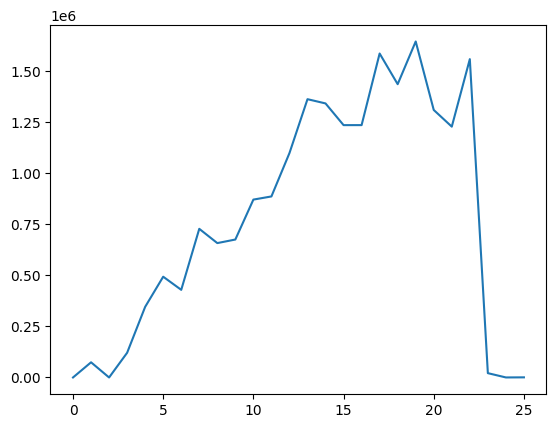

In [76]:
plt.plot(range(len(profits_during_time)), profits_during_time['profit'])
#now we have made a big picture of the sells' behaviour during the months and unfortunatelly we can see a huge decreasement in the profit


####Our first hypothesis is by increasing the prices of the best category product will this lead to bigger profit, because as we can see the the profits after 2019 are decreasing fast, so to prevent it we can build a model to help us raise the prices in the most profitable way

In [77]:
#for our training sample we will get only the sequential months and if there are missing values between two months we will ignore them
#we will only get the non-missing values
profits_per_month = np.array(profits_during_time['profit'][2:24])
profits_per_month # so now we have removed the data for the non-sequential months

array([1.96200000e+01, 1.20802990e+05, 3.45309510e+05, 4.92557600e+05,
       4.28403780e+05, 7.26588840e+05, 6.56864990e+05, 6.74329860e+05,
       8.69492440e+05, 8.84892690e+05, 1.09680214e+06, 1.36030362e+06,
       1.33953601e+06, 1.23346079e+06, 1.23354102e+06, 1.58349182e+06,
       1.43359116e+06, 1.64234567e+06, 1.30758967e+06, 1.22601411e+06,
       1.55595082e+06, 2.11624000e+04])

Now preparing the data to train our model


In [78]:
X = []
y = []

for i in range(len(profits_per_month)-3):
    X.append(profits_per_month[i:i+3])
    y.append(profits_per_month[i+3])

X = np.array(X)
y = np.array(y)


#### Now after gathering the data - we need the profits from the last three months, we will train a Time Series ML model, se the process will look like - for the current month profit - y our model will learn from the last three months and find a pattern in the selss behaviour


In [79]:
model = LinearRegression()
X_train = X[:16]
y_train = y[:16]

X_test=  X[16:]
y_test = y[16:]

model.fit(X_train, y_train)
model.score(X_test, y_test)
test_data = np.array([[1555950.82, 21162.40, 175.34]])
model.predict(test_data)
#we can see that our model is not exactly accurate due to the fact that the data has 'spikes' hige amplitudes - and the data is not enough
#lets try to look per days

array([528213.2455869])

In [80]:
profits_during_time = product_sells.groupby(['year', 'month', 'day'])['payment_value'].sum().reset_index()
profits_during_time.rename(columns={'payment_value' : 'profit'}, inplace=True)
profits_during_time

,year,month,day,profit
0,2016,09,19,75.06
1,2016,10,08,1203.82
2,2016,10,09,3088.20
3,2016,10,10,10863.82
4,2016,10,11,10728.32
...,...,...,...,...
550,2018,09,14,757.57
551,2018,09,18,1024.76
552,2020,02,03,90.69
553,2020,02,05,84.65


In [81]:
#we need to scale the dots of the months - so to have more accuracy - we can not treat the profits as a values from evenly
#spread points - because there are missing days, so my idea is to scale them appropiely
#let's fix year 2016 the ninth month as the starting point - we want to find a function passing through the profit points during time
#scaling formula = 365.(year-2016) + 30*month + days - now we can slice the time axis into intervals
#so lets build our new scaling column

In [82]:
profits_during_time['year'] = profits_during_time['year'].astype(int)
profits_during_time['month'] = profits_during_time['month'].astype(int)
profits_during_time['day'] = profits_during_time['day'].astype(int)

profits_during_time['scaler'] = 365*(profits_during_time['year']-2016) + 30*profits_during_time['month'] + profits_during_time['day']
profits_during_time

,year,month,day,profit,scaler
0,2016,9,19,75.06,289
1,2016,10,8,1203.82,308
2,2016,10,9,3088.20,309
3,2016,10,10,10863.82,310
4,2016,10,11,10728.32,311
...,...,...,...,...,...
550,2018,9,14,757.57,1014
551,2018,9,18,1024.76,1018
552,2020,2,3,90.69,1523
553,2020,2,5,84.65,1525


In [83]:
X = np.array([profits_during_time['scaler']]).reshape(-1,1)
y = np.array([profits_during_time['profit']]).reshape(-1,1)

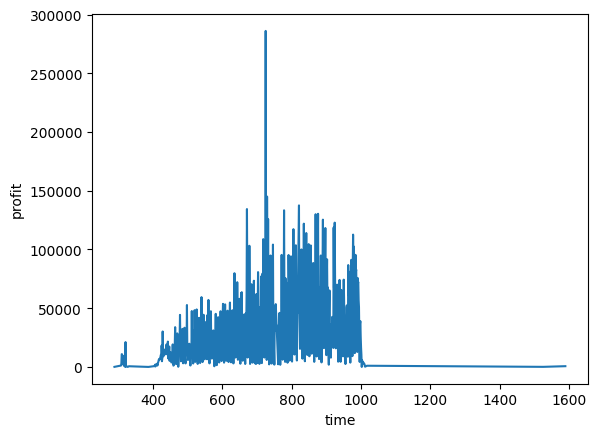

In [84]:
plt.plot(X, y)
plt.xlabel('time')
plt.ylabel('profit')
plt.show()

In [85]:
degree = 3
poly_reg = PolynomialFeatures(degree=degree)
X_poly = poly_reg.fit_transform(X)
#here we use the basis [1,x,x^2,x^3] and for each passed point x we calculate it -> []
#then these vectors are treated as input values for the Linear Regression Model
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

LinearRegression()

In [86]:
def basisPol(x):
  return [1, x, x**2, x**3]

In [87]:
poly_model.predict([basisPol(2222)])
#we can see thankfully to this model which days there is the risk to be on loss
#that is really not good - we can see a pattern that along the days the losses increase
#POSSIBLE WAYS TO AVOID THIS SCENARIO
#1.Which are the risky months - we have created a model below to tell us the most frequently bought product and increase its price a little bit
#so to prevent the potential money lost

array([[-242778.10631182]])

In [120]:
best_sells_helper = product_sells.groupby(['year', 'month', 'product_category_name'])['payment_value'].sum()
best_categories = best_sells_helper.groupby(['year', 'month']).apply(lambda x: x.sort_values(ascending=False).index[0][2]).reset_index(name='category_name')

#so now we decided to analyze which category's products are the most sold per each month
#we could also try to see a pattern or seasonability - so to generate the best profit
#we can create a model classifier which helps us to pedict the category with the most sold products
#and increase a little bit their prices and to prepare the needed amount, so to be able to sell the most of it
#to the customers


,year,month,category_name
0,2016,09,telefonia
1,2016,10,moveis_decoracao
2,2016,12,fashion_bolsas_e_acessorios
3,2017,01,moveis_decoracao
4,2017,02,moveis_decoracao
5,2017,03,moveis_decoracao
6,2017,04,cama_mesa_banho
7,2017,05,informatica_acessorios
8,2017,06,informatica_acessorios
9,2017,07,cama_mesa_banho


In [89]:
X_input = np.array([m,p] for m in best_categories['month'] for p in best_categories['category_name'])

In [90]:
months = np.array([best_categories['month']])
categories = np.array([best_categories['category_name']])
X_input = months.reshape(-1, 1)
y = categories.reshape(-1, 1)

In [91]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_input, y)

model.predict([[1]])
#we can see that we have build a model classifier to predict us the most profitable category per month

array(['informatica_acessorios'], dtype=object)

In [92]:
#analyzing the diagram, showing the behaviour of the profits we can - after the second year there is a huge decreasement in prices
#so I come up with an algorithm - first for each month we will use the model to tell us the most wanted category
#then we will increase the price with some percentage and see what happens
product_sells['year'] = product_sells['year'].astype(int)
filtered_per_year = product_sells[product_sells['year'] >= 2018]
filtered_per_year
filtered_per_year['price']

,price
0,79.80
1,17.00
4,113.57
5,34.35
6,34.35
...,...
117591,149.90
117593,175.00
117595,179.80
117596,297.00


In [93]:
def update_price(row, perc):
  m = row['month']
  best_cat = model.predict([[m]])[0]
  if best_cat == row['product_category_name']:
    row['price'] = row['price'] *(1 + perc)
    row['payment_value'] = row['payment_value'] + row['freight_value']
  return row

In [94]:
filtered_per_year = filtered_per_year.apply(lambda row: update_price(row, 1.2), axis=1)
#we can see how some of the prices and payments have changed, so now its time to compare it to with the prev one

In [95]:
filtered_per_year

,payment_sequential,payment_installments,payment_value,shipping_limit_date,price,freight_value,product_category_name,year,month,day
0,1,8,99.33,2018-05-02 22:15:09,79.80,19.53,casa_construcao,2018,05,02
1,1,1,24.39,2018-07-02 11:18:58,17.00,7.39,automotivo,2018,07,02
4,1,2,128.45,2018-05-31 16:14:41,113.57,14.88,cama_mesa_banho,2018,05,31
5,1,2,96.12,2018-05-11 15:31:11,34.35,13.71,cama_mesa_banho,2018,05,11
6,1,2,96.12,2018-05-11 15:31:11,34.35,13.71,cama_mesa_banho,2018,05,11
...,...,...,...,...,...,...,...,...,...,...
117591,1,10,170.14,2018-06-20 13:31:54,149.90,20.24,informatica_acessorios,2018,06,20
117593,1,1,194.11,2018-03-12 20:30:39,175.00,19.11,audio,2018,03,12
117595,1,2,198.94,2018-05-22 12:30:57,179.80,19.14,brinquedos,2018,05,22
117596,1,1,363.31,2018-03-15 03:55:25,297.00,66.31,construcao_ferramentas_iluminacao,2018,03,15


In [96]:
filtered_per_year = filtered_per_year.sort_values(by=['year', 'month', 'day'])
profit_by_month = filtered_per_year.groupby(['year', 'month'])['payment_value'].sum().reset_index(name='profit')
profit_by_month



,year,month,profit
0,2018,01,1243906.54
1,2018,02,1248676.55
2,2018,03,1602032.03
3,2018,04,1448958.35
4,2018,05,1652621.40
5,2018,06,1324188.93
6,2018,07,1243336.71
7,2018,08,1575758.72
8,2018,09,21426.56
9,2020,02,175.34


In [97]:
profit_by_month

,year,month,profit
0,2018,01,1243906.54
1,2018,02,1248676.55
2,2018,03,1602032.03
3,2018,04,1448958.35
4,2018,05,1652621.40
5,2018,06,1324188.93
6,2018,07,1243336.71
7,2018,08,1575758.72
8,2018,09,21426.56
9,2020,02,175.34


In [98]:
filtered_profits_after_2018 = profits_during_time[profits_during_time['year'] >= 2018]
filtered_profits_after_2018 = filtered_profits_after_2018.groupby(['year', 'month'])['profit'].sum().reset_index(name='profit')
filtered_profits_after_2018


,year,month,profit
0,2018,1,1233460.79
1,2018,2,1233541.02
2,2018,3,1583491.82
3,2018,4,1433591.16
4,2018,5,1642345.67
5,2018,6,1307589.67
6,2018,7,1226014.11
7,2018,8,1555950.82
8,2018,9,21162.40
9,2020,2,175.34


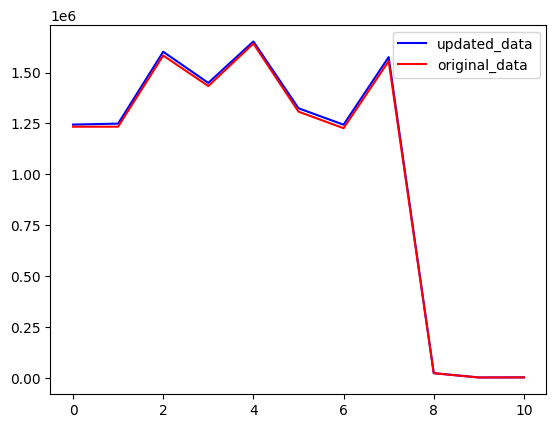

In [143]:
plt.plot(range(len(profit_by_month)), profit_by_month['profit'], color='blue', label = 'updated_data')
plt.plot(range(len(filtered_profits_after_2018)), filtered_profits_after_2018['profit'], color = 'red', label='original_data')
plt.legend()
plt.show()
#our algorithm is working

In [100]:
#the difference is too small to capture so we can just calculate the difference
diff = profit_by_month['profit']-filtered_profits_after_2018['profit']
print(diff)

0     10445.75
1     15135.53
2     18540.21
3     15367.19
4     10275.73
5     16599.26
6     17322.60
7     19807.90
8       264.16
9         0.00
10        0.00
Name: profit, dtype: float64


####As we can see there is a really small difference - then let's come up with another model - this time we will take a few of the best categories and increase their prices

In [101]:
#So these are a huge numbers - all this numbers are added to our profit due to the fact that we have only increase the price by 2
#it will be kind od strange to increase the price only to the products from one category by two times - the customers will notice and stop buying - so what
#so wouldnt be better to increase the products from few categories by for eaxmple thirty percents than increasing just one category by two hundred percents
#if you are a customer there is a less chance to notice if a few categories' products prices have increased by 5-6 % then just one category increased by 50%

In [160]:
best_sells = product_sells.groupby(['year', 'month', 'product_category_name'])['payment_value'].sum().reset_index(name='profit')
k = 2
topKbestcategories = best_sells.sort_values(['year', 'month', 'profit'], ascending=[True, True, False]).groupby(['year', 'month']).head(k)
topKbestcategories
#so first we sort ascending by year, month and then descending by profit

categories = np.array(topKbestcategories['product_category_name'])
double_months = np.array(topKbestcategories['month'])
months = double_months[1::2] #means start from the first idx and take each second element
#months = np.array([double_months[i] for i in range(1, 2*(len(double_months))-1, 2)])

In [149]:
# topKbestcategories = topKbestcategories[topKbestcategories.groupby(['year', 'month'])['product_category_name'].count()>=k]
#we want to get a valid training data so we need for one [x] -> maps k categories [y1,..yk]
#so firsly we need to remove the months that dont have k best categories
topKbestcategories = topKbestcategories.groupby(['year', 'month']).filter(lambda x: len(x) >= k)
topKbestcategories

,year,month,product_category_name,profit
24,2016,10,moveis_decoracao,11125.00
26,2016,10,perfumaria,7201.84
58,2017,01,moveis_decoracao,19315.22
46,2017,01,esporte_lazer,13994.04
107,2017,02,moveis_decoracao,33673.83
75,2017,02,beleza_saude,30702.44
160,2017,03,moveis_decoracao,47772.17
130,2017,03,cama_mesa_banho,38726.96
181,2017,04,cama_mesa_banho,31662.15
212,2017,04,moveis_decoracao,31493.19


In [161]:
X_input = months.reshape(-1, 1)
Y = categories.reshape(-1, k)
modelK = DecisionTreeClassifier()
modelK.fit(X_input, Y)


DecisionTreeClassifier()

In [132]:
def update_priceK(row, perc_array):
  m = row['month']
  best_cat = modelK.predict([[m]])[0].tolist()
  if row['product_category_name'] in best_cat:
    idx = best_cat.index(row['product_category_name'])
    perc = perc_array[idx]
    row['price'] = row['price'] * (1 + perc)
    row['payment_value'] = row['price'] + row['freight_value']

  return row
#if a category in the table in the given month is in top k categories then increase it with the % from the perc_array


In [145]:
product_sells_updated = product_sells.apply(lambda row: update_priceK(row, [0.6,0.5]),axis=1)

In [134]:
product_sells_updated

,payment_sequential,payment_installments,payment_value,shipping_limit_date,price,freight_value,product_category_name,year,month,day
0,1,8,99.33,2018-05-02 22:15:09,79.80,19.53,casa_construcao,2018,05,02
1,1,1,58.39,2018-07-02 11:18:58,51.00,7.39,automotivo,2018,07,02
2,1,1,65.71,2017-12-26 09:52:34,56.99,8.72,perfumaria,2017,12,26
3,1,8,287.58,2017-12-12 12:13:20,269.70,17.88,cama_mesa_banho,2017,12,12
4,1,2,355.59,2018-05-31 16:14:41,340.71,14.88,cama_mesa_banho,2018,05,31
...,...,...,...,...,...,...,...,...,...,...
117596,1,1,363.31,2018-03-15 03:55:25,297.00,66.31,construcao_ferramentas_iluminacao,2018,03,15
117597,1,2,96.80,2017-08-24 10:04:56,79.00,17.80,papelaria,2017,08,24
117598,1,1,47.77,2017-11-27 17:46:05,39.99,7.78,automotivo,2017,11,27
117599,1,5,1416.54,2018-08-13 23:45:00,1396.00,20.54,beleza_saude,2018,08,13


####So now we have updated, based on the three best categories - passing the percentage of price raises in an array for each product - so now we can test with multiple combination of % variables and see which percent works best for the category to generate the maximum profit

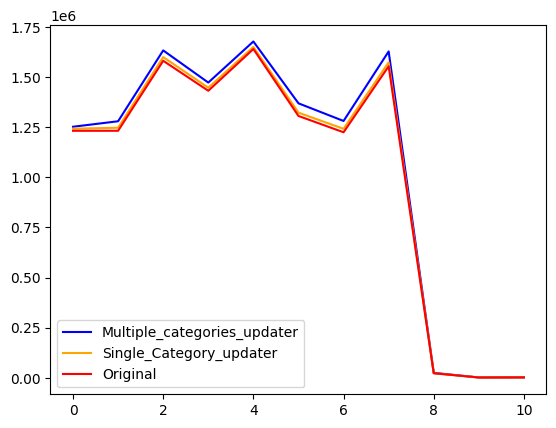

In [146]:
f2 = product_sells_updated[product_sells_updated['year'] >= 2018]
f2 = f2.groupby(['year', 'month'])['payment_value'].sum().reset_index(name='profit')
filtered_profits_after_2018

plt.plot(range(len(f2)), f2['profit'], color='blue', label = 'Multiple_categories_updater')
plt.plot(range(len(profit_by_month)), profit_by_month['profit'], color='orange', label = 'Single_Category_updater')
plt.plot(range(len(filtered_profits_after_2018)), filtered_profits_after_2018['profit'], color='red', label = 'Original')
plt.legend()
plt.show()


####That proves our hypothesis that we can increase with a small % the products of a few categories and generate a bigger profit than increasing only one product category with a huge percentage.

###💵 In conclusion we can say, that using our algorithm to increase slightly the prices - it generates us bigger profit - if we only mofidy the best category prices the profit won't be noticable, but if we generalize the algorithm to update price per k cathegories then we minimize the chances for potential losses.
###Another interesting observation ,even though we change the prices and generate bigger profit - all the three scenarios end with falit.